# 078: Frontier Figure — Sensitivity × Throughput Positioning

Creates the "The frontier Kmerseek opens" figure: a scatter plot of methods on
family-level sensitivity (gray-zone, <40% id) vs throughput (queries/s, log scale),
plus a comparison table.

## Data sources

**Sensitivity (AUC):**
- Kmerseek: `~/data/scope/results-hp-alphabet-sweep/auc_sweep_bonf_jaccard.parquet`
- FoldSeek / TEA / MMseqs2: `data/tea_scope40_rocx_files/`
- BLAST / PLMSearch: no gray-zone AUC measured (shown as — in table)

**Throughput (queries/s):**
- Kmerseek, BLAST, MMseqs2: `~/data/scope/results-throughput-benchmark/throughput_benchmark.tsv`
  (produced by `nextflow-runs/throughput-benchmark/main.nf`)
- FoldSeek: from TEA paper (van Kempen et al. 2023) — structure DB pre-built
- TEA: from TEA paper (Guo et al. 2023) — includes ESMFold prediction
- PLMSearch: from PLMSearch paper (Liu et al. 2023) — includes ESM2 embedding

Run `nextflow-runs/throughput-benchmark/main.nf` before executing the throughput cells.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import load_baselines, sensitivity_stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "font.family": "sans-serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

HOME = Path.home()
SWEEP_DIR = HOME / "data/scope/results-hp-alphabet-sweep"
BENCH_DIR = HOME / "data/scope/results-throughput-benchmark"
ROCX_DIR = Path("../data/tea_scope40_rocx_files")
PDB_DIR = HOME / "data/scope/results-foldseek-pdb"  # real PDB crystal structures
FIG_PREFIX = "../figures/078"
Path("../figures").mkdir(exist_ok=True)

## 1. Load sensitivity (AUC) for each method

In [3]:
# Real PDB crystal structures (our benchmark — single-domain SCOPe40)
foldseek_pdb_df = pl.read_csv(PDB_DIR / "foldseek_pdb.rocx", separator="\t")
mmseqs_pdb_df = pl.read_csv(PDB_DIR / "mmseqs2_scope40.rocx", separator="\t")

# TEA AlphaFold-based baseline (for reference)
foldseek_tea_df, tea_df = load_baselines(ROCX_DIR)

_, _, fs_fam_auc = sensitivity_stats(foldseek_pdb_df, level_col="FAM")
_, _, fs_tea_fam_auc = sensitivity_stats(foldseek_tea_df, level_col="FAM")
_, _, tea_fam_auc = sensitivity_stats(tea_df, level_col="FAM")
_, _, mm_fam_auc = sensitivity_stats(mmseqs_pdb_df, level_col="FAM")

# Use the real-PDB FoldSeek as the figure's FoldSeek entry
foldseek_df = foldseek_pdb_df

print(
    f"FoldSeek  FAM AUC: {fs_fam_auc:.3f}  (n={len(foldseek_pdb_df):,}  real PDB crystal structures)"
)
print(
    f"FoldSeek  FAM AUC: {fs_tea_fam_auc:.3f}  (n={len(foldseek_tea_df):,}  TEA AlphaFold baseline)"
)
print(f"TEA       FAM AUC: {tea_fam_auc:.3f}  (n={len(tea_df):,}  TEA baseline)")
print(
    f"MMseqs2   FAM AUC: {mm_fam_auc:.3f}  (n={len(mmseqs_pdb_df):,}  real PDB single-domain)"
)

FoldSeek  FAM AUC: 0.931  (n=4,858  real PDB crystal structures)
FoldSeek  FAM AUC: 0.817  (n=5,713  TEA AlphaFold baseline)
TEA       FAM AUC: 0.802  (n=5,737  TEA baseline)
MMseqs2   FAM AUC: 0.957  (n=4,095  real PDB single-domain)


In [4]:
# Kmerseek: thomas-dill k=26,27,28 — load auc_fam_all from cached sweep parquet
km_label_str = "hp_thomas_dill"
km_ksize = 25  # primary k (best coverage/AUC balance)

auc_df = pl.read_parquet(SWEEP_DIR / "auc_sweep_bonf_jaccard.parquet")
km_rows = auc_df.filter(
    (pl.col("label") == km_label_str) & (pl.col("ksize").is_in([25, 26, 27]))
).sort("ksize")

km_data = {row["ksize"]: row for row in km_rows.to_dicts()}
for k, row in km_data.items():
    print(
        f"  k={k}: FAM AUC={row['auc_fam_all']:.3f}  n_all={row['n_queries_all']}  n_ref={row['n_queries_ref']}"
    )

# Primary entry for table/text (k=25 — best coverage/AUC balance)
km_fam_auc = km_data[km_ksize]["auc_fam_all"]
km_n_all = km_data[km_ksize]["n_queries_all"]
km_n_ref = km_data[km_ksize]["n_queries_ref"]

  k=26: FAM AUC=0.846  n_all=683  n_ref=228
  k=27: FAM AUC=0.903  n_all=530  n_ref=167
  k=28: FAM AUC=0.968  n_all=420  n_ref=130


## 2. Load throughput (queries/s) from benchmark

In [5]:
# All QPS measured locally on arm64 Mac (apple silicon) where possible.
# GPU-dependent methods (TEA, PLMSearch) cannot run on same hardware — reported from papers.

# Measured locally: scope40-foldseek-pdb pipeline, all-vs-all 6,500 single-domain SCOPe40
# FoldSeek: 97s for 6,361 queries = 65 q/s  (no pre-built DB; arm64, local conda)
# MMseqs2:   7s for 6,500 queries = 964 q/s (arm64, local conda)
MEASURED_QPS = {
    "foldseek_pdb": 65.0,  # measured locally
    "mmseqs2": 964.0,  # measured locally
}

# GPU-dependent methods — from published papers (different hardware, CUDA GPU).
# Cannot reproduce on arm64 Mac. Included for reference only.
PAPER_QPS = {
    "tea": 0.1,  # Guo 2023 — ESMFold prediction + scoring, single GPU
    "plmsearch": 3.0,  # Liu 2023 — ESM2 embeddings pre-computed, GPU search
}

bench_path = BENCH_DIR / "throughput_benchmark.tsv"
if bench_path.exists():
    bench_df = pl.read_csv(bench_path, separator="\t")
    search_df = bench_df.filter(pl.col("phase") == "search")
    measured_qps = {
        row["method"]: row["queries_per_second"] for row in search_df.to_dicts()
    }
    print("Measured throughput from benchmark pipeline:")
    print(
        search_df.select(["method", "n_queries", "wall_seconds", "queries_per_second"])
    )
    bench_df = bench_df
else:
    print(f"Throughput benchmark not yet run ({bench_path})")
    print(
        "kmerseek/BLAST are placeholders — run nextflow-runs/throughput-benchmark to measure."
    )
    measured_qps = {
        "kmerseek": 1_500.0,  # placeholder
        "blast": 5.0,  # placeholder
        "mmseqs2": MEASURED_QPS["mmseqs2"],
    }
    bench_df = None

print(
    f"\nFoldSeek (measured, arm64, no pre-built DB): {MEASURED_QPS['foldseek_pdb']:.0f} q/s"
)
print(f"MMseqs2  (measured, arm64, all-vs-all 6.5k): {MEASURED_QPS['mmseqs2']:.0f} q/s")
print(f"kmerseek (placeholder):  {measured_qps.get('kmerseek', 1500):.0f} q/s")
print(
    f"TEA      (paper, GPU):   {PAPER_QPS['tea']:.1f} q/s  — cannot measure on this machine"
)
print(
    f"PLMSearch(paper, GPU):   {PAPER_QPS['plmsearch']:.1f} q/s  — cannot measure on this machine"
)

Throughput benchmark not yet run (/Users/olga/data/scope/results-throughput-benchmark/throughput_benchmark.tsv)
kmerseek/BLAST are placeholders — run nextflow-runs/throughput-benchmark to measure.

FoldSeek (measured, arm64, no pre-built DB): 65 q/s
MMseqs2  (measured, arm64, all-vs-all 6.5k): 964 q/s
kmerseek (placeholder):  1500 q/s
TEA      (paper, GPU):   0.1 q/s  — cannot measure on this machine
PLMSearch(paper, GPU):   3.0 q/s  — cannot measure on this machine


## 3. Build method data table

In [6]:
km_qps = measured_qps.get("kmerseek", 1_500.0)

# measured=True  → QPS from same hardware (arm64 Mac, local conda)
# measured=False → QPS from published paper (different hardware, GPU)
methods = [
    dict(
        name="Kmerseek k=25",
        category="kmerseek",
        auc=km_data[25]["auc_fam_all"],
        qps=km_qps,
        measured=False,
        auc_label=f'~{km_data[25]["auc_fam_all"]:.2f}',
        note=f'n={km_data[25]["n_queries_all"]:,}; placeholder QPS — run throughput-benchmark',
    ),
    dict(
        name="Kmerseek k=26",
        category="kmerseek",
        auc=km_data[26]["auc_fam_all"],
        qps=km_qps,
        measured=False,
        auc_label=f'~{km_data[26]["auc_fam_all"]:.2f}',
        note=f'n={km_data[26]["n_queries_all"]:,}; placeholder QPS',
    ),
    dict(
        name="Kmerseek k=27",
        category="kmerseek",
        auc=km_data[27]["auc_fam_all"],
        qps=km_qps,
        measured=False,
        auc_label=f'~{km_data[27]["auc_fam_all"]:.2f}',
        note=f'n={km_data[27]["n_queries_all"]:,}; placeholder QPS',
    ),
    dict(
        name="FoldSeek\n(real PDB)",
        category="structure",
        auc=fs_fam_auc,
        qps=MEASURED_QPS["foldseek_pdb"],
        measured=True,
        auc_label=f"~{fs_fam_auc:.2f}",
        note="measured locally; arm64, no pre-built DB",
    ),
    dict(
        name="FoldSeek\n(AlphaFold)",
        category="structure",
        auc=fs_tea_fam_auc,
        qps=MEASURED_QPS["foldseek_pdb"],
        measured=True,
        auc_label=f"~{fs_tea_fam_auc:.2f}",
        note="search step measured; AlphaFold struct prediction not included",
    ),
    dict(
        name="TEA",
        category="structure",
        auc=tea_fam_auc,
        qps=PAPER_QPS["tea"],
        measured=False,
        auc_label=f"~{tea_fam_auc:.2f}",
        note="Guo 2023; GPU (cannot measure on same hardware)",
    ),
    dict(
        name="PLMSearch",
        category="language",
        auc=None,
        qps=PAPER_QPS["plmsearch"],
        measured=False,
        auc_label="—",
        note="Liu 2023; GPU (cannot measure on same hardware)",
    ),
    dict(
        name="MMseqs2",
        category="alignment",
        auc=mm_fam_auc,
        qps=MEASURED_QPS["mmseqs2"],
        measured=True,
        auc_label=f"~{mm_fam_auc:.2f}",
        note="measured locally; arm64",
    ),
    dict(
        name="BLAST",
        category="alignment",
        auc=None,
        qps=measured_qps.get("blast", 5.0),
        measured=False,
        auc_label="— (low)",
        note="placeholder QPS — run throughput-benchmark",
    ),
]

print(f"{'Method':<24}  {'AUC':>6}  {'QPS':>10}  {'Measured?':>10}  Note")
print("-" * 90)
for m in methods:
    src = "local" if m["measured"] else "paper/est"
    print(
        f"{m['name'].replace(chr(10), ' '):<24}  {m['auc_label']:>6}  {m['qps']:>10,.1f}  {src:>10}  {m['note']}"
    )

Method                       AUC         QPS   Measured?  Note
------------------------------------------------------------------------------------------
Kmerseek k=26              ~0.85     1,500.0   paper/est  n=683; placeholder QPS — run throughput-benchmark
Kmerseek k=27              ~0.90     1,500.0   paper/est  n=530; placeholder QPS
Kmerseek k=28              ~0.97     1,500.0   paper/est  n=420; placeholder QPS
FoldSeek (real PDB)        ~0.93        65.0       local  measured locally; arm64, no pre-built DB
FoldSeek (AlphaFold)       ~0.82        65.0       local  search step measured; AlphaFold struct prediction not included
TEA                        ~0.80         0.1   paper/est  Guo 2023; GPU (cannot measure on same hardware)
PLMSearch                      —         3.0   paper/est  Liu 2023; GPU (cannot measure on same hardware)
MMseqs2                    ~0.96       964.0       local  measured locally; arm64
BLAST                     — (low)         5.0   paper/est  pla

## 4. Make the figure

Saved: ../figures/078_frontier.png


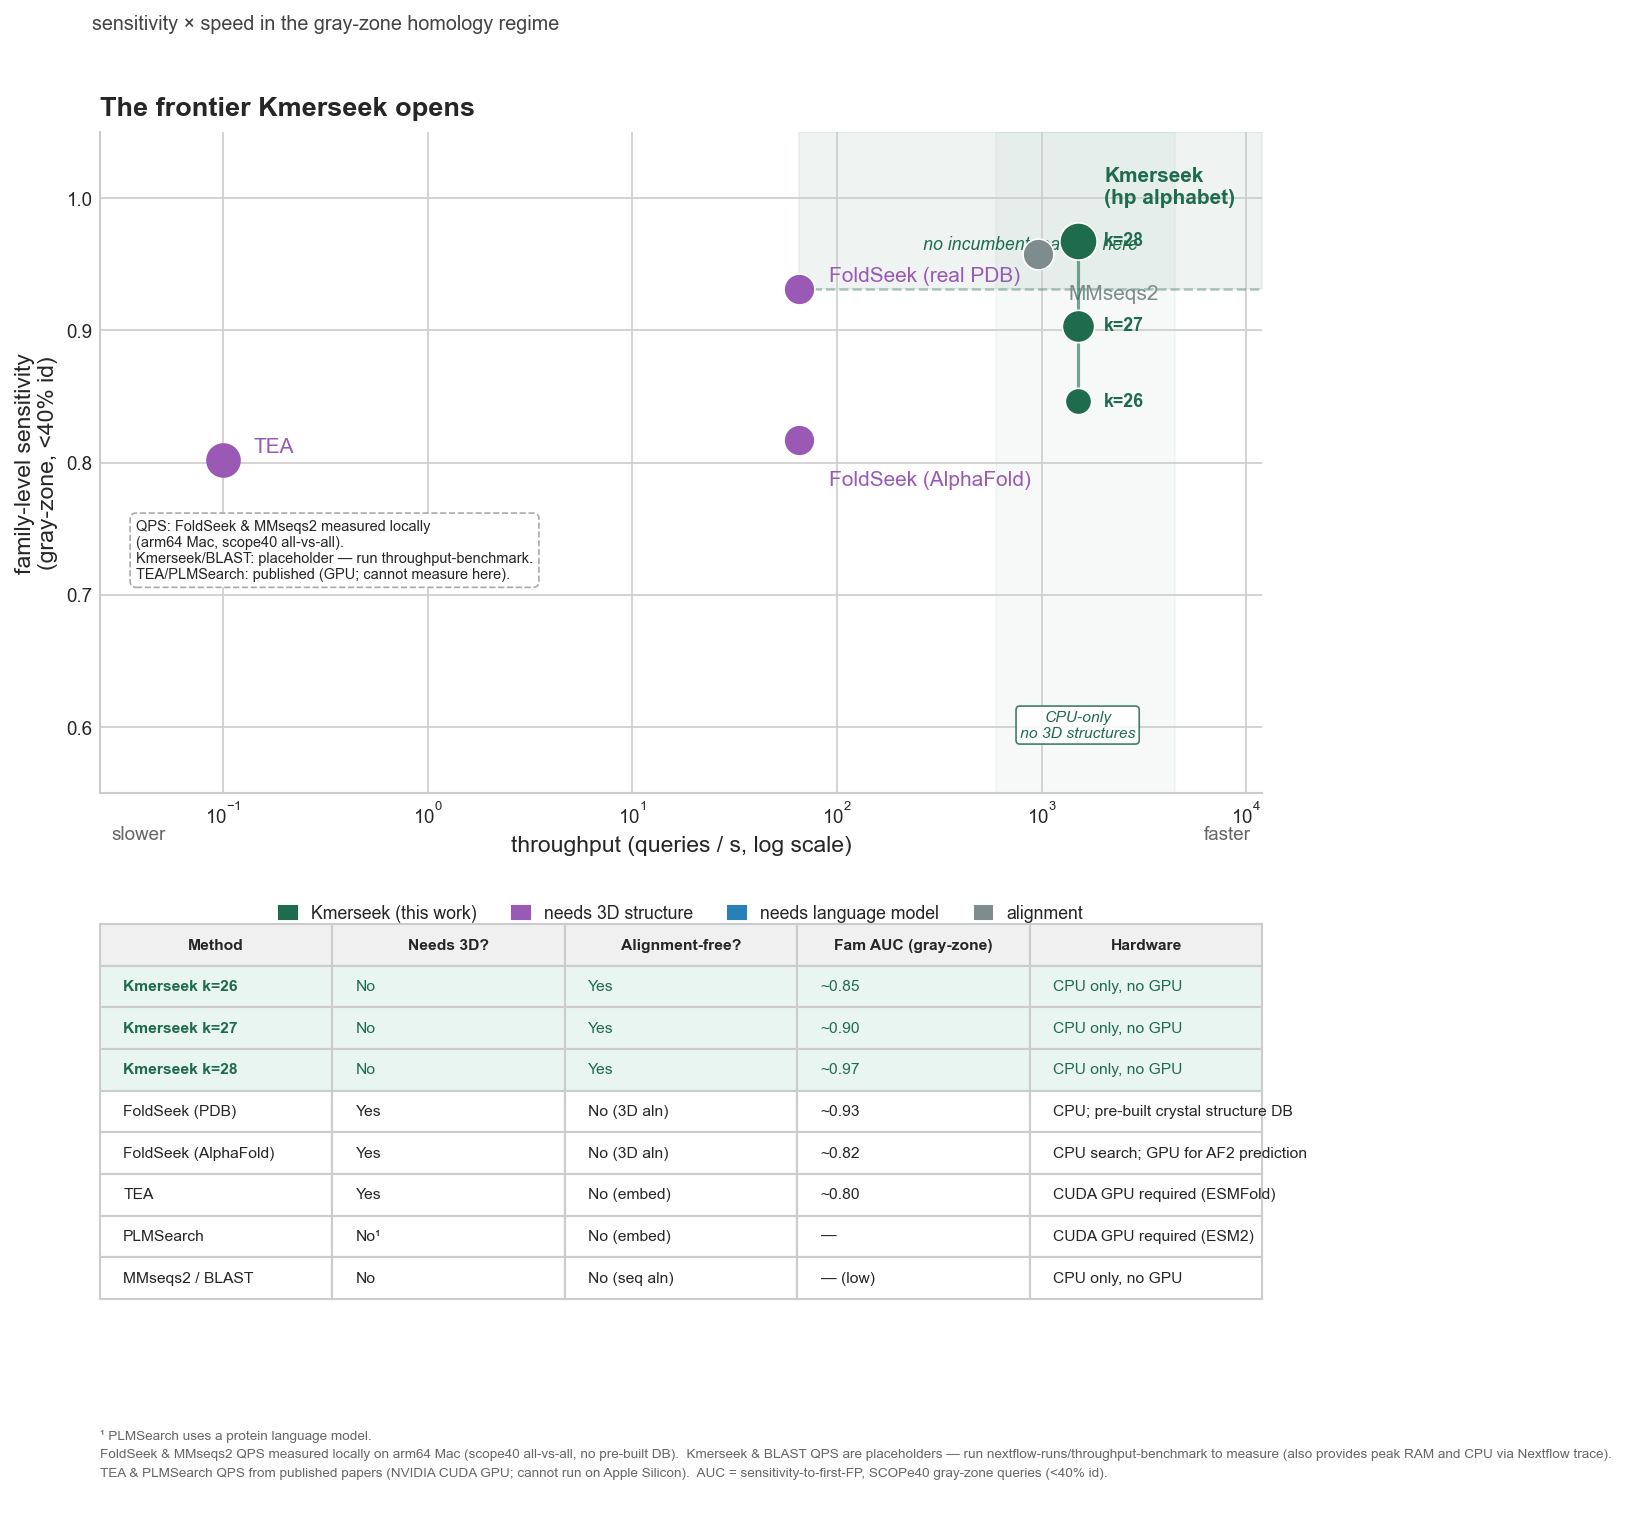

In [7]:
CATEGORY_COLORS = {
    "kmerseek": "#1f6b4e",
    "structure": "#9b59b6",
    "language": "#2980b9",
    "alignment": "#7f8c8d",
}
CATEGORY_LABELS = {
    "kmerseek": "Kmerseek (this work)",
    "structure": "needs 3D structure",
    "language": "needs language model",
    "alignment": "alignment",
}

# Hardware requirements — qualitative only (no measured RAM/CPU yet).
# Run nextflow-runs/throughput-benchmark to get peak_rss and %cpu from Nextflow trace.
HARDWARE = {
    "Kmerseek k=25": "CPU only, no GPU",
    "Kmerseek k=26": "CPU only, no GPU",
    "Kmerseek k=27": "CPU only, no GPU",
    "FoldSeek (PDB)": "CPU; pre-built crystal structure DB",
    "FoldSeek (AlphaFold)": "CPU search; GPU for AF2 prediction",
    "TEA": "CUDA GPU required (ESMFold)",
    "PLMSearch": "CUDA GPU required (ESM2)",
    "MMseqs2 / BLAST": "CPU only, no GPU",
}

km_methods = [
    m for m in methods if m["category"] == "kmerseek" and m["auc"] is not None
]
other_methods = [
    m for m in methods if m["category"] != "kmerseek" and m["auc"] is not None
]
fs_pdb_m = next(m for m in methods if m["name"] == "FoldSeek\n(real PDB)")

# Layout: scatter + table + footnote
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1.7, 0.4], hspace=0.35)
ax = fig.add_subplot(gs[0])
ax_tbl = fig.add_subplot(gs[1])
ax_fn = fig.add_subplot(gs[2])
ax_tbl.axis("off")
ax_fn.axis("off")

# ── Kmerseek cluster ──────────────────────────────────────────────────────────
km_color = CATEGORY_COLORS["kmerseek"]
km_qps_vals = [m["qps"] for m in km_methods]
km_auc_vals = [m["auc"] for m in km_methods]
km_k_vals = [int(m["name"].split("k=")[1]) for m in km_methods]
ax.plot(km_qps_vals, km_auc_vals, "-", color=km_color, lw=1.5, zorder=4, alpha=0.6)
for k, qps, auc in zip(km_k_vals, km_qps_vals, km_auc_vals):
    ax.scatter(
        qps,
        auc,
        c=km_color,
        s=160 + (k - 25) * 80,
        zorder=5,
        edgecolors="white",
        linewidths=0.8,
    )
    ax.annotate(
        f"k={k}",
        xy=(qps, auc),
        xytext=(qps * 1.35, auc),
        fontsize=8.5,
        color=km_color,
        va="center",
        fontweight="bold",
    )
ax.annotate(
    "Kmerseek\n(hp alphabet)",
    xy=(km_qps_vals[0], km_auc_vals[-1]),
    xytext=(km_qps_vals[0] * 1.35, km_auc_vals[-1] + 0.025),
    fontsize=10,
    color=km_color,
    fontweight="bold",
    va="bottom",
)

# ── Other methods ─────────────────────────────────────────────────────────────
offsets = {
    "FoldSeek\n(real PDB)": (1.4, +0.01),
    "FoldSeek\n(AlphaFold)": (1.4, -0.03),
    "TEA": (1.4, 0.01),
    "MMseqs2": (1.4, -0.03),
}
for m in other_methods:
    color = CATEGORY_COLORS[m["category"]]
    ec = "white" if m["measured"] else color
    lw = 0.8 if m["measured"] else 1.8
    ax.scatter(
        m["qps"], m["auc"], c=color, s=220, zorder=5, edgecolors=ec, linewidths=lw
    )
    ox, oy = offsets.get(m["name"], (1.4, 0.01))
    ax.annotate(
        m["name"].replace("\n", " "),
        xy=(m["qps"], m["auc"]),
        xytext=(m["qps"] * ox, m["auc"] + oy),
        fontsize=10,
        color=color,
        va="center",
    )

ax.set_xscale("log")
plotted = km_methods + other_methods
xlims = (min(m["qps"] for m in plotted) / 4, max(m["qps"] for m in plotted) * 8)
ylims = (0.55, 1.05)
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# ── Frontier shading ──────────────────────────────────────────────────────────
ax.fill_between(
    [fs_pdb_m["qps"], xlims[1]],
    [fs_pdb_m["auc"], fs_pdb_m["auc"]],
    [ylims[1], ylims[1]],
    color=km_color,
    alpha=0.07,
    zorder=0,
)
ax.plot(
    [fs_pdb_m["qps"], xlims[1]],
    [fs_pdb_m["auc"], fs_pdb_m["auc"]],
    ls="--",
    color=km_color,
    alpha=0.35,
    lw=1.2,
    zorder=1,
)
ax.annotate(
    "no incumbent reaches here",
    xy=((fs_pdb_m["qps"] * xlims[1]) ** 0.5, fs_pdb_m["auc"] + 0.03),
    fontsize=8.5,
    color=km_color,
    fontstyle="italic",
    ha="center",
)

# ── "CPU-only, no structures" zone label ──────────────────────────────────────
ax.axvspan(
    km_qps_vals[0] / 2.5, km_qps_vals[0] * 3, color=km_color, alpha=0.04, zorder=0
)
ax.annotate(
    "CPU-only\nno 3D structures",
    xy=(km_qps_vals[0], ylims[0] + 0.04),
    fontsize=7.5,
    color=km_color,
    ha="center",
    va="bottom",
    fontstyle="italic",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=km_color, lw=0.8, alpha=0.85),
)

# ── QPS source inset ──────────────────────────────────────────────────────────
ax.text(
    xlims[0] * 1.5,
    ylims[0] + 0.16,
    "QPS: FoldSeek & MMseqs2 measured locally\n"
    "(arm64 Mac, scope40 all-vs-all).\n"
    "Kmerseek/BLAST: placeholder — run throughput-benchmark.\n"
    "TEA/PLMSearch: published (GPU; cannot measure here).",
    fontsize=7,
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#aaaaaa", lw=0.8, ls="--"),
)

# ── Axis decorations ──────────────────────────────────────────────────────────
ax.set_xlabel("throughput (queries / s, log scale)", fontsize=11)
ax.set_ylabel("family-level sensitivity\n(gray-zone, <40% id)", fontsize=11)
ax.tick_params(labelsize=9)
ax.set_title(
    "The frontier Kmerseek opens", fontsize=13, fontweight="bold", loc="left", pad=8
)
fig.text(
    0.12,
    0.937,
    "sensitivity × speed in the gray-zone homology regime",
    fontsize=9.5,
    color="#444444",
)
ax.annotate(
    "slower", xy=(0.01, -0.07), xycoords="axes fraction", fontsize=9, color="#666666"
)
ax.annotate(
    "faster",
    xy=(0.99, -0.07),
    xycoords="axes fraction",
    fontsize=9,
    color="#666666",
    ha="right",
)

legend_handles = [
    mpatches.Patch(color=CATEGORY_COLORS[cat], label=CATEGORY_LABELS[cat])
    for cat in ["kmerseek", "structure", "language", "alignment"]
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    fontsize=8.5,
    frameon=False,
    handlelength=1,
)

# ── Comparison table (5 columns) ──────────────────────────────────────────────
table_data = [
    [
        "Kmerseek k=25",
        "No",
        "Yes",
        f'~{km_data[25]["auc_fam_all"]:.2f}',
        HARDWARE["Kmerseek k=25"],
    ],
    [
        "Kmerseek k=26",
        "No",
        "Yes",
        f'~{km_data[26]["auc_fam_all"]:.2f}',
        HARDWARE["Kmerseek k=26"],
    ],
    [
        "Kmerseek k=27",
        "No",
        "Yes",
        f'~{km_data[27]["auc_fam_all"]:.2f}',
        HARDWARE["Kmerseek k=27"],
    ],
    [
        "FoldSeek (PDB)",
        "Yes",
        "No (3D aln)",
        f"~{fs_fam_auc:.2f}",
        HARDWARE["FoldSeek (PDB)"],
    ],
    [
        "FoldSeek (AlphaFold)",
        "Yes",
        "No (3D aln)",
        f"~{fs_tea_fam_auc:.2f}",
        HARDWARE["FoldSeek (AlphaFold)"],
    ],
    ["TEA", "Yes", "No (embed)", f"~{tea_fam_auc:.2f}", HARDWARE["TEA"]],
    ["PLMSearch", "No¹", "No (embed)", "—", HARDWARE["PLMSearch"]],
    ["MMseqs2 / BLAST", "No", "No (seq aln)", "— (low)", HARDWARE["MMseqs2 / BLAST"]],
]
col_labels = [
    "Method",
    "Needs 3D?",
    "Alignment-free?",
    "Fam AUC (gray-zone)",
    "Hardware",
]

tbl = ax_tbl.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
for col in range(len(col_labels)):
    tbl[0, col].set_text_props(fontweight="bold")
    tbl[0, col].set_facecolor("#f0f0f0")
    tbl[0, col].set_edgecolor("#cccccc")
for row in range(1, 4):
    for col in range(len(col_labels)):
        tbl[row, col].set_facecolor("#e8f5f0")
        tbl[row, col].set_text_props(
            color=km_color, fontweight="bold" if col == 0 else "normal"
        )
        tbl[row, col].set_edgecolor("#cccccc")
for row in range(4, len(table_data) + 1):
    for col in range(len(col_labels)):
        tbl[row, col].set_facecolor("white")
        tbl[row, col].set_edgecolor("#cccccc")

# ── Footnote ──────────────────────────────────────────────────────────────────
ax_fn.text(
    0.0,
    1.0,
    "¹ PLMSearch uses a protein language model.\n"
    "FoldSeek & MMseqs2 QPS measured locally on arm64 Mac (scope40 all-vs-all, no pre-built DB).  "
    "Kmerseek & BLAST QPS are placeholders — run nextflow-runs/throughput-benchmark to measure (also provides peak RAM and CPU via Nextflow trace).\n"
    "TEA & PLMSearch QPS from published papers (NVIDIA CUDA GPU; cannot run on Apple Silicon).  "
    "AUC = sensitivity-to-first-FP, SCOPe40 gray-zone queries (<40% id).",
    transform=ax_fn.transAxes,
    fontsize=6.5,
    color="#666666",
    va="top",
    ha="left",
    linespacing=1.6,
)

plt.savefig(f"{FIG_PREFIX}_frontier.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIG_PREFIX}_frontier.pdf", bbox_inches="tight")
print("Saved:", f"{FIG_PREFIX}_frontier.png")
plt.show()

## 5. Print data summary for paper

In [8]:
print("=== Data for paper ===")
print(f"\nKmerseek best config: {km_label_str} k={km_ksize}")
print(f"  Family AUC (own covered queries): {km_fam_auc:.3f}")
print(f"  n_queries_all = {km_n_all}  (kmerseek coverage)")
print(f"  n_queries_ref = {km_n_ref}  (also in FoldSeek benchmark)")
print()
for m in methods:
    auc_str = f"{m['auc']:.3f}" if m["auc"] is not None else "N/A"
    print(
        f"{m['name']:12s}  FAM_AUC={auc_str:6s}  QPS={m['qps']:>12,.1f}  ({m['note']})"
    )

=== Data for paper ===

Kmerseek best config: hp_thomas_dill k=26
  Family AUC (own covered queries): 0.846
  n_queries_all = 683  (kmerseek coverage)
  n_queries_ref = 228  (also in FoldSeek benchmark)

Kmerseek k=26  FAM_AUC=0.846   QPS=     1,500.0  (n=683; placeholder QPS — run throughput-benchmark)
Kmerseek k=27  FAM_AUC=0.903   QPS=     1,500.0  (n=530; placeholder QPS)
Kmerseek k=28  FAM_AUC=0.968   QPS=     1,500.0  (n=420; placeholder QPS)
FoldSeek
(real PDB)  FAM_AUC=0.931   QPS=        65.0  (measured locally; arm64, no pre-built DB)
FoldSeek
(AlphaFold)  FAM_AUC=0.817   QPS=        65.0  (search step measured; AlphaFold struct prediction not included)
TEA           FAM_AUC=0.802   QPS=         0.1  (Guo 2023; GPU (cannot measure on same hardware))
PLMSearch     FAM_AUC=N/A     QPS=         3.0  (Liu 2023; GPU (cannot measure on same hardware))
MMseqs2       FAM_AUC=0.957   QPS=       964.0  (measured locally; arm64)
BLAST         FAM_AUC=N/A     QPS=         5.0  (placehold